In [1]:
# Data Analysis Case Study - Car Dekho
# In this case study Car Data is provided as input in the form of csv file.
# We have to perform Data Analysis on it and
# We have to find the answers of the questions mentioned in the case study.

# Importing essential packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Importing the data and taking a look at it
data = pd.read_csv('/content/Dataset-Car Market Trends Analysis with Car Dekho Data.csv')
# Display the first 5 rows of the dataset
data.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


There are different questions we can answer by analysing this data -
1. From which manufacturing year to which manufacturing year vehicles are present in this data ?
2. What is the lowest price to which a vehicle is sold?
3. What is the highest price to which a vehicle is sold?
4. How many records are there in this data?
5. Are there any missing records in this data?
6. How many different vehicles are present in this data ?
7. Which is the most sold vehicle in this data?
8. Which is the least sold vehicle in this data?
9. Does the database include any CNG vehicle?
10. How many vehicles here are for sell from Individuals directly?
11. Does this database contain auto transmission vehicles?
12. How many single person owned vehicles are there in this database?
13. Which is the most cost depreciated vehicle in data ?
14. Which is the least cost depreciated vehicle in data ?
15. Are there any factors which you feel affect the cost depreciation ?
16. In general selling price is affected by age of vehicle and distance driven by vehicle, is it observable from data?
17. Can we get idea about newest vehicles i.e. after 2015 manufactured?
18. Which is the oldest car sold here?
19. Which is the newest car sold here?

In [3]:
# Display the last 5 rows of the dataset to check the end of the data
data.tail()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [4]:
# Return the total number of rows and columns in the dataset
data.shape

(301, 9)

In [5]:
# To check the statistical features of the data
data.describe() # The statistical features are only for numerical values

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


From above analysis one can say that -
1. The data here contains cars with manufacturing year 2003 to 2018.
2. The lowest price on which car was sold is INR 10,000/-.
3. The highest price on which the car was sold is INR 35 lacs.
4. There are 301 records in the data.

In [6]:
# To look at the variables in detail
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [7]:
# Count the number of missing or null values in each column
data.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


From above analysis one can say that -
1. None of the variables or columns here have null values.
2. Variables "Car_Name", "Fuel_Type", "Seller_Type" and "Transmission" are non-numeric in nature.

In [8]:
# Checking whether non-numeric variables are categorical in nature
print(data.Car_Name.value_counts())

Car_Name
city                  26
corolla altis         16
verna                 14
fortuner              11
brio                  10
                      ..
Honda Activa 125       1
Hero Hunk              1
Hero  Ignitor Disc     1
Hero  CBZ Xtreme       1
Bajaj  ct 100          1
Name: count, Length: 98, dtype: int64


<Axes: xlabel='count', ylabel='Car_Name'>

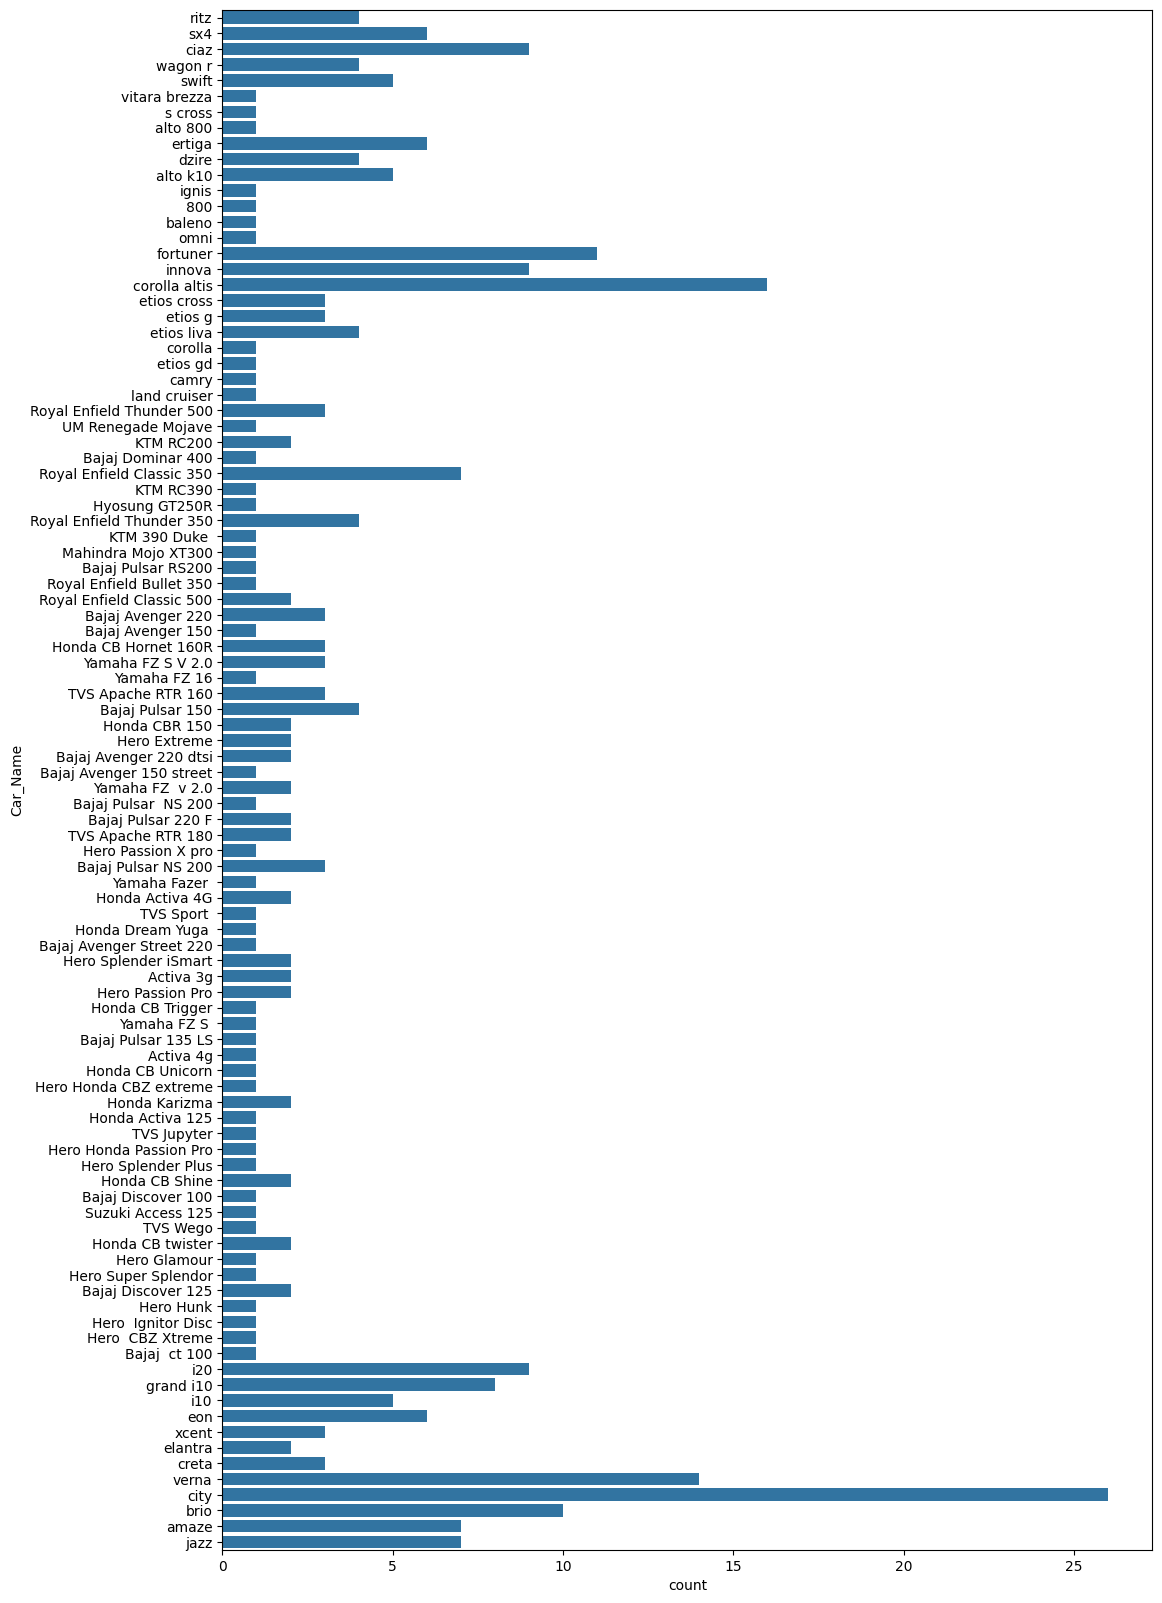

In [9]:
# Create a horizontal bar chart to count car occurrences
fig_dims = (12,20)
fig, ax = plt.subplots(figsize=fig_dims)
sns.countplot(y=data.Car_Name, ax=ax, data=data)

There are 98 different vehicles in the data. It contains bikes and mopeds too. Variable is categorical.

In [10]:
# Find and print the name of the vehicle that appears most frequently in the data
print(data['Car_Name'].value_counts().idxmax())


city


In [11]:
# Find and print the name of the vehicle that appears least frequently in the data
print(data['Car_Name'].value_counts().idxmin())


Hyosung GT250R


In [12]:
# Count how many vehicles run on Petrol vs Diesel vs CNG
print(data.Fuel_Type.value_counts())

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64


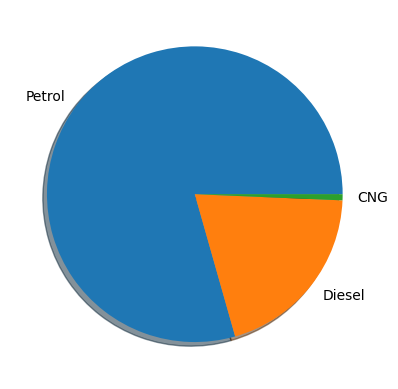

In [13]:
# Display a pie chart showing the distribution proportion of different fuel types
plt.pie(data.Fuel_Type.value_counts(), labels = ["Petrol", "Diesel", "CNG"], shadow=True)
plt.show()

<Axes: xlabel='Fuel_Type'>

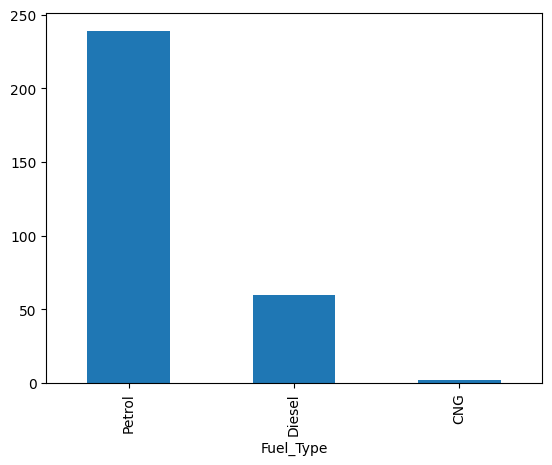

In [14]:
# Generate a simple vertical bar chart to compare fuel type counts
data.Fuel_Type.value_counts().plot.bar()

The data contains mostly petrol vehicles. This variable is skewed. Variable is categorical.

In [15]:
# Count how many cars are sold by Dealers vs Individuals
print(data.Seller_Type.value_counts())

Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64


In [16]:
# Count how many cars are Manual vs Automatic transmission
print(data.Transmission.value_counts())

Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


In [17]:
# Count cars based on their number of previous owners
print(data.Owner.value_counts())

Owner
0    290
1     10
3      1
Name: count, dtype: int64


In [18]:
# Calculate vehicle age using 2026 as the reference year
data['Vehicle_Age'] = 2026 - data['Year']
# Calculate money lost by subtracting selling price from showroom price
data['Depreciation'] = data['Present_Price'] - data['Selling_Price']

In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
 9   Vehicle_Age    301 non-null    int64  
 10  Depreciation   301 non-null    float64
dtypes: float64(3), int64(4), object(4)
memory usage: 26.0+ KB


In [20]:
# Show statistical summary (mean, min, max, etc.) transposed for better readability
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,301.0,2013.627907,2.891554,2003.00,2012.00,2014.00,2016.00,2018.0
Selling_Price,301.0,4.661296,5.082812,0.10,0.90,3.60,6.00,35.0
Present_Price,301.0,7.628472,8.644115,0.32,1.20,6.40,9.90,92.6
Kms_Driven,301.0,36947.205980,38886.883882,500.00,15000.00,32000.00,48767.00,500000.0
Owner,301.0,0.043189,0.247915,0.00,0.00,0.00,0.00,3.0
Vehicle_Age,301.0,12.372093,2.891554,8.00,10.00,12.00,14.00,23.0
Depreciation,301.0,2.967176,4.828771,0.03,0.39,1.64,3.35,57.6


In [21]:
# Find and print the car with the highest cost depreciation
print(data.loc[data.Depreciation.idxmax(), ['Car_Name', 'Depreciation']])

Car_Name        land cruiser
Depreciation            57.6
Name: 86, dtype: object


In [22]:
# Find and print the car with the lowest cost depreciation
print(data.loc[data.Depreciation.idxmin(), ['Car_Name', 'Depreciation']])

Car_Name        Honda Activa 4G
Depreciation               0.03
Name: 155, dtype: object


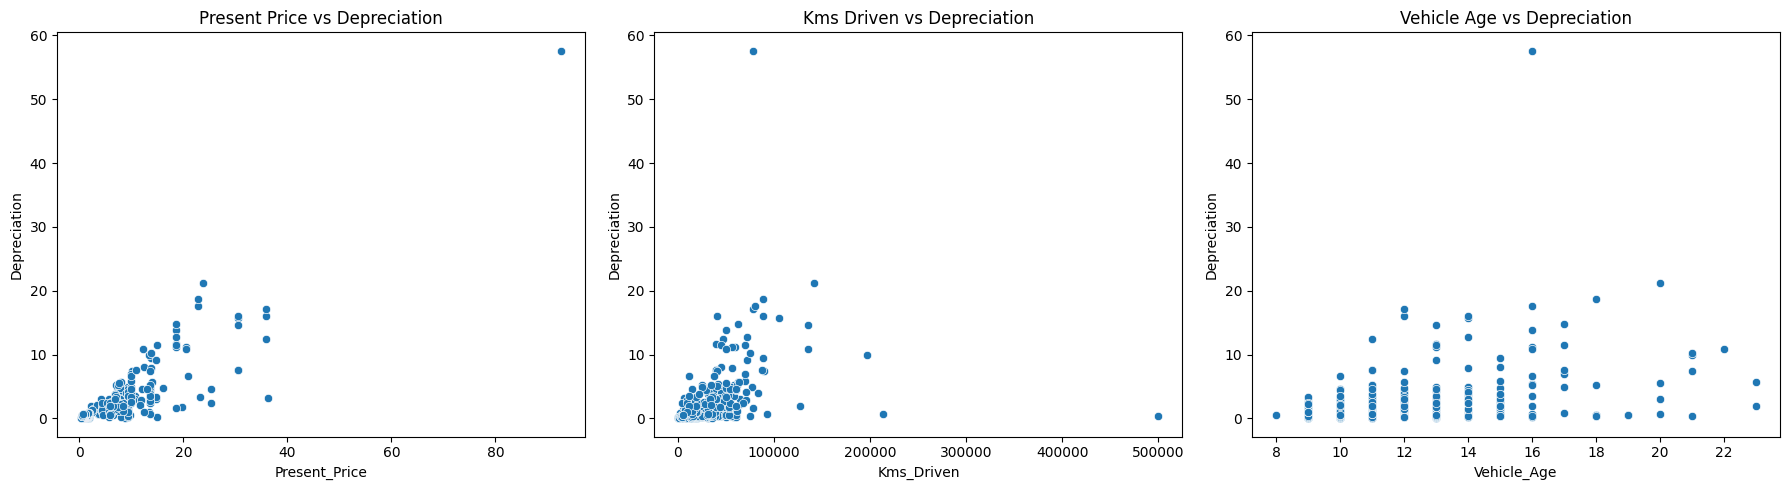

In [23]:
# Setup canvas for 3 scatter plots to check numerical factors affecting depreciation
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
sns.scatterplot(data=data, x='Present_Price', y='Depreciation')
plt.title('Present Price vs Depreciation')

plt.subplot(1, 3, 2)
sns.scatterplot(data=data, x='Kms_Driven', y='Depreciation')
plt.title('Kms Driven vs Depreciation')

plt.subplot(1, 3, 3)
sns.scatterplot(data=data, x='Vehicle_Age', y='Depreciation')
plt.title('Vehicle Age vs Depreciation')
plt.tight_layout()
plt.show()

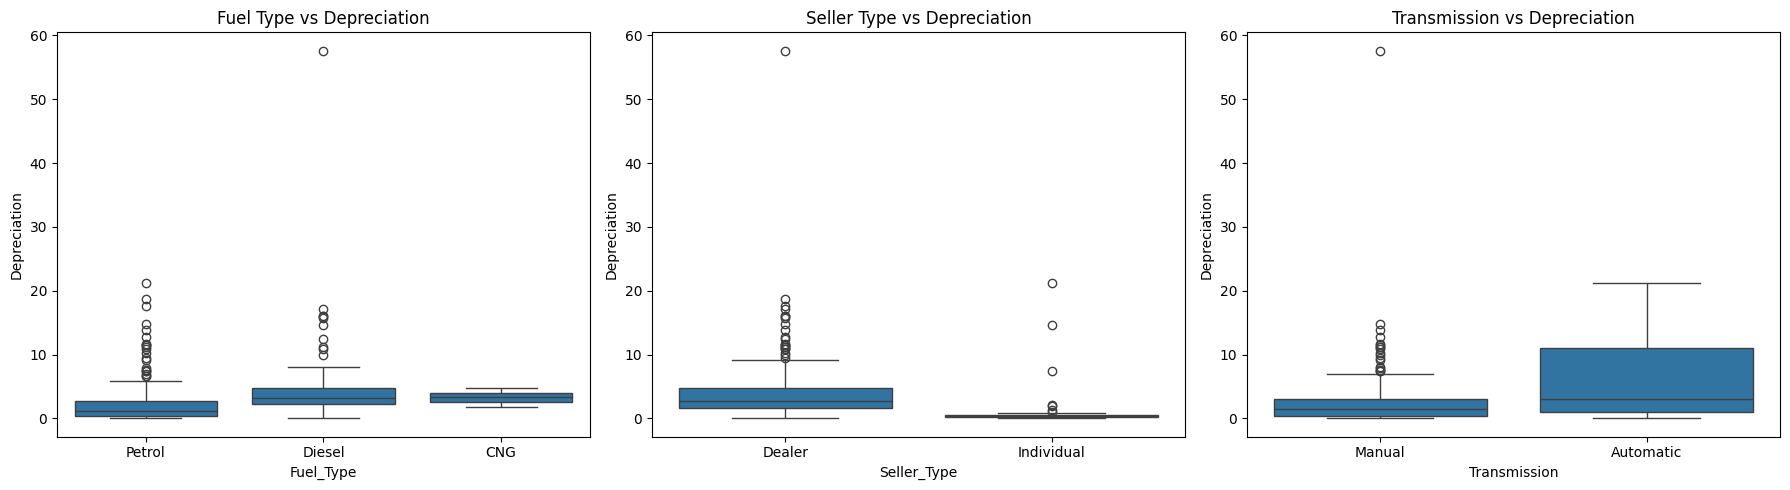

In [24]:
# Setup canvas for 3 box plots to check categorical factors affecting depreciation
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
sns.boxplot(data=data, x='Fuel_Type', y='Depreciation')
plt.title('Fuel Type vs Depreciation')

plt.subplot(1, 3, 2)
sns.boxplot(data=data, x='Seller_Type', y='Depreciation')
plt.title('Seller Type vs Depreciation')

plt.subplot(1, 3, 3)
sns.boxplot(data=data, x='Transmission', y='Depreciation')
plt.title('Transmission vs Depreciation')
plt.tight_layout()
plt.show()

In [25]:
# Compute correlation matrix for only numerical columns
corr = data.select_dtypes(include='number').corr()
# Apply a color heatmap to easily see strong relationships between features
corr.style.background_gradient(cmap='coolwarm')

,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Vehicle_Age,Depreciation
Year,1.000000,0.236141,-0.047584,-0.524342,-0.182104,-1.000000,-0.333746
Selling_Price,0.236141,1.000000,0.878983,0.029187,-0.088344,-0.236141,0.520881
Present_Price,-0.047584,0.878983,1.000000,0.203647,0.008057,0.047584,0.864902
Kms_Driven,-0.524342,0.029187,0.203647,1.000000,0.089216,0.524342,0.333832
Owner,-0.182104,-0.088344,0.008057,0.089216,1.000000,0.182104,0.107415
Vehicle_Age,-1.000000,-0.236141,0.047584,0.524342,0.182104,1.000000,0.333746
Depreciation,-0.333746,0.520881,0.864902,0.333832,0.107415,0.333746,1.000000


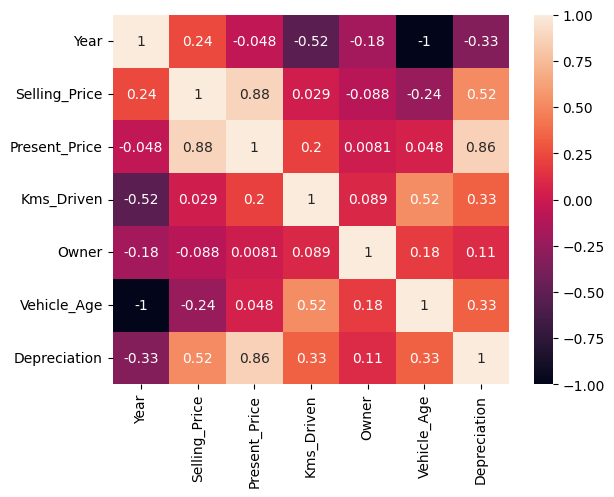

In [26]:
# Generate a visual heatmap with correlation values printed inside each box
sns.heatmap(data.select_dtypes(include='number').corr(), annot=True)
plt.show()


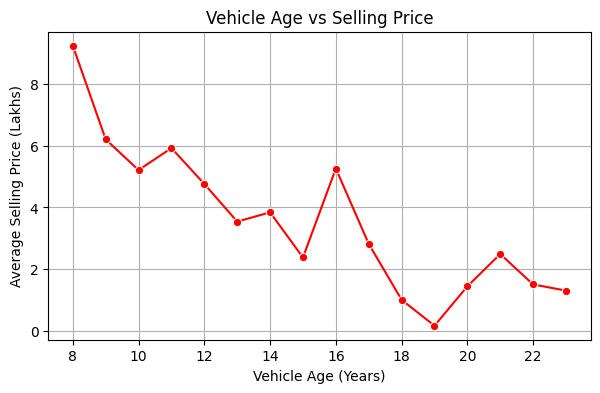

In [27]:
# Plot trend line showing how average selling price drops as vehicle age increases
plt.figure(figsize=(7, 4))
sns.lineplot(data=data, x='Vehicle_Age', y='Selling_Price', marker='o', color='red', errorbar=None)
plt.title('Vehicle Age vs Selling Price')
plt.xlabel('Vehicle Age (Years)')
plt.ylabel('Average Selling Price (Lakhs)')
plt.grid(True)
plt.show()


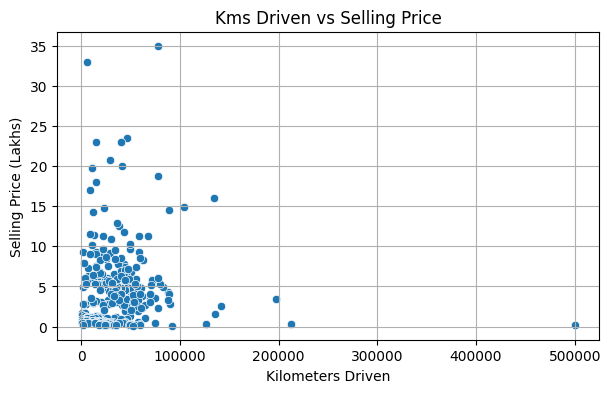

In [28]:
# Plot scatter chart to check how driving distance affects the selling price
plt.figure(figsize=(7, 4))
sns.scatterplot(data=data, x='Kms_Driven', y='Selling_Price')
plt.title('Kms Driven vs Selling Price')
plt.xlabel('Kilometers Driven')
plt.ylabel('Selling Price (Lakhs)')
plt.grid(True)
plt.show()

In [29]:
# Filter dataset to select only vehicles manufactured after the year 2015
newest_vehicles = data[data['Year'] > 2015]
print("Total vehicles manufactured after 2015:", len(newest_vehicles))
newest_vehicles.head()

Total vehicles manufactured after 2015: 86


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Vehicle_Age,Depreciation
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9,2.60
5,vitara brezza,2018,9.25,9.83,2071,Diesel,Dealer,Manual,0,8,0.58
8,ciaz,2016,8.75,8.89,20273,Diesel,Dealer,Manual,0,10,0.14
10,alto 800,2017,2.85,3.60,2135,Petrol,Dealer,Manual,0,9,0.75
15,ertiga,2016,7.75,10.79,43000,Diesel,Dealer,Manual,0,10,3.04


In [30]:
# Find and print details of the oldest car in the dataset
print(data.loc[data['Year'].idxmin(), ['Car_Name', 'Year', 'Selling_Price']])

Car_Name          800
Year             2003
Selling_Price    0.35
Name: 37, dtype: object


In [31]:
# Find and print details of the newest car in the dataset
print(data.loc[data['Year'].idxmax(), ['Car_Name', 'Year', 'Selling_Price']])

Car_Name         vitara brezza
Year                      2018
Selling_Price             9.25
Name: 5, dtype: object
